# About Unsupervised Learning/Cluster Analysis

[See more: ](https://www.naftaliharris.com/blog/visualizing-k-means-clustering/)

Unsupervised data mining includes methods that discover unknown relationships in data. With unsupervised data mining, there’s no outcome that is being predicted; rather, patterns in the data are sought that perhaps were previously unknown. For example, one may want to find groups of customers with similar purchase patterns. In some cases, unsupervised analyses are used as the approach and the knowledge gained therefrom is presented to stakeholders. In other cases, unsupervised analyses are used to find relationships and patterns that can, in turn, be used to build predictive models for efficiently and effectively.

Unsupervised learning algorithms are also referred to as clustering algorithms. The basic idea is to analyze the shared correlation in the data we use as an input to the algorithm. Correlation is a well known way to check if two quantitative variables are related. Cluster algorithms are more advanced as they consider the correlation between a set of variables.

What does this mean for how the algorithms relate to our desired outcome? Our desired outcome is that we are able to group the rows of a data set together in some novel way such that the rows are related via the input variables. This means that we need a set of variables that have interesting variance patterns (more on this a little later). It also means that we need to be measuring some real set of relationships AND that we have collected data that accurately represents those relationships. This means that clustering projects can fail for a few interesting reasons.

First, a cluster solution can fail (or be difficult to find) because the population of individuals we're interested in are homogeneous. I once worked on a project for a high-end auto manufacturer. It turned out that a decent solution was difficult simply because the people surveyed tended to be all in the same income bracket, cared (more or less) about the same thing, and even shared similar demographic patterns. Similar phenomena can be found if you're looking to cluster specific professions. For example, clustering data collected from doctors can be tough, especially if there is a focus on specific specialties.

Similarly, data collection can have a large effect on the ability to get a good cluster solution. I once worked on a project where we were, again, clustering data collected in a survey. The survey designer had decided to use a three point agreement scale in the questions that were to be used as inputs. This was a really bad idea since cluster algorithms live and die on the variance w/in the data. We would typically use a five point scale at a minimum and would prefer seven to eleven points as more points allow for more variance.

### About the data

This is a small dataset from 1973 on protein consumption from nine different food groups in 25 countries in Europe. The goal is to group the countries based on patterns in their protein consumption.

References: 1. Zumel, N. and Mount, J. “Practical Data Science with R”, Manning Publications, 2014.

### Developing a cluster solution

The process of creating a good/usable cluster solution typically involves a bit of art along with the science. Cluster algorithms produce different solutions depending on what variables are used as inputs and can be different under different transformations of the data. By transformations we mean things like scaling, bucketing, or turning the variable into binary values. A typical process would go as follows.

1.  Explore the data (via numeric summarise and graphic visualization)
2.  Choose a set of variables
3.  Choose a transformation method (none being a viable option)
4.  Run several cluster algorithms
5.  Evaluate solutions
    -   If there are no viable solutions, go back to step 2 and repeat
6.  Present solution to stakeholders

We will walk through each of these steps throughout the lab and ask questions along the way.

### Load the data from a MySQL Database hosted in GCP


In [1]:
#install the required packages
install.packages("fpc")
install.packages("RMySQL")
install.packages("summarytools")

# Downloading packages -------------------------------------------------------
- Downloading fpc from CRAN ...                 OK [839.6 Kb in 0.21s]
- Downloading mclust from CRAN ...              OK [3.9 Mb in 0.21s]
- Downloading flexmix from CRAN ...             OK [1.7 Mb in 0.22s]
- Downloading prabclus from CRAN ...            OK [470.2 Kb in 0.2s]
- Downloading diptest from CRAN ...             OK [170.2 Kb in 0.19s]
- Downloading robustbase from CRAN ...          OK [3 Mb in 0.21s]
- Downloading DEoptimR from CRAN ...            OK [72.8 Kb in 0.21s]
- Downloading kernlab from CRAN ...             OK [1.9 Mb in 0.2s]
Successfully downloaded 8 packages in 3.6 seconds.

The following package(s) will be installed:
- DEoptimR   [1.1-3]
- diptest    [0.77-1]
- flexmix    [2.3-19]
- fpc        [2.2-12]
- kernlab    [0.9-33]
- mclust     [6.1.1]
- prabclus   [2.3-3]
- robustbase [0.99-4]
These packages will be installed into "~/renv/library/linux-ubuntu-jammy/R-4.4/x86_64-pc-linux-gn

In [ ]:
library(ggplot2)
library(fpc)
library(tidyverse)
library(ggrepel)
library(RMySQL)
library(magrittr)

mm <- src_mysql(
  host='[updateme]',
  port=3306,
  user='admin',
  password='[updateme]',
  dbname='unsupervised_learning'
)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ lubridate 1.9.3     ✔ tibble    3.2.1
✔ purrr     1.0.2     ✔ tidyr     1.3.1
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Loading required package: DBI


Attaching package: ‘magrittr’


The following object is masked from ‘package:purrr’:

    set_names


The following object is masked from ‘package:tidyr’:

    extract


Warning message:
“`src_mysql()` was deprecated in dplyr 1.0.0.
ℹ Please use `tbl()` directly with a database connection”


### Explore the data

One thing often done prior to running a cluster algorithm is to explore the data. This is first done by examining summary stats as seen below.

In [3]:
d_protein <- tbl(mm,'protein') %>% collect() # Get data from the database
summary(d_protein) 

Warning message in dbSendQuery(conn, statement, ...):
“Decimal MySQL column 1 imported as numeric”
Warning message in dbSendQuery(conn, statement, ...):
“Decimal MySQL column 2 imported as numeric”
Warning message in dbSendQuery(conn, statement, ...):
“Decimal MySQL column 3 imported as numeric”
Warning message in dbSendQuery(conn, statement, ...):
“Decimal MySQL column 4 imported as numeric”
Warning message in dbSendQuery(conn, statement, ...):
“Decimal MySQL column 5 imported as numeric”
Warning message in dbSendQuery(conn, statement, ...):
“Decimal MySQL column 6 imported as numeric”
Warning message in dbSendQuery(conn, statement, ...):
“Decimal MySQL column 7 imported as numeric”
Warning message in dbSendQuery(conn, statement, ...):
“Decimal MySQL column 8 imported as numeric”
Warning message in dbSendQuery(conn, statement, ...):
“Decimal MySQL column 9 imported as numeric”
Warning message in dbSendQuery(con, sql):
“Decimal MySQL column 1 imported as numeric”
Warning message in dbS

   Country             RedMeat       WhiteMeat          Eggs     
 Length:25          Min.   : 4.0   Min.   : 1.00   Min.   :1.00  
 Class :character   1st Qu.: 8.0   1st Qu.: 5.00   1st Qu.:3.00  
 Mode  :character   Median :10.0   Median : 8.00   Median :3.00  
                    Mean   : 9.8   Mean   : 7.92   Mean   :3.08  
                    3rd Qu.:11.0   3rd Qu.:11.00   3rd Qu.:4.00  
                    Max.   :18.0   Max.   :14.00   Max.   :5.00  
      Milk            Fish          Cereals          Starch          Nuts     
 Min.   : 5.00   Min.   : 0.00   Min.   :19.00   Min.   :1.00   Min.   :1.00  
 1st Qu.:11.00   1st Qu.: 2.00   1st Qu.:24.00   1st Qu.:3.00   1st Qu.:2.00  
 Median :18.00   Median : 3.00   Median :28.00   Median :5.00   Median :2.00  
 Mean   :17.28   Mean   : 4.28   Mean   :32.32   Mean   :4.36   Mean   :3.08  
 3rd Qu.:23.00   3rd Qu.: 6.00   3rd Qu.:40.00   3rd Qu.:6.00   3rd Qu.:5.00  
 Max.   :34.00   Max.   :14.00   Max.   :57.00   Max.   :7.00   

In [4]:
library(summarytools)
descr(d_protein) %>% t()

Warning message:
“no DISPLAY variable so Tk is not available”
system might not have X11 capabilities; in case of errors when using dfSummary(), set st_options(use.x11 = FALSE)


Attaching package: ‘summarytools’


The following object is masked from ‘package:tibble’:

    view




,Mean,Std.Dev,Min,Q1,Median,Q3,Max,MAD,IQR,CV,Skewness,SE.Skewness,Kurtosis,N.Valid,Pct.Valid
Cereals,32.32,11.010298,19,24,28,40,57,8.8956,16,0.3406652,0.84109509,0.4636835,-0.47880906,25,100
Eggs,3.08,1.115049,1,3,3,4,5,1.4826,1,0.3620288,-0.32240579,0.4636835,-0.60837682,25,100
Fish,4.28,3.470351,0,2,3,6,14,2.9652,4,0.8108296,1.01415769,0.4636835,0.44178264,25,100
FrAndVeg,4.20,1.914854,1,3,4,5,8,1.4826,2,0.4559177,0.51273782,0.4636835,-0.90593058,25,100
Milk,17.28,7.097652,5,11,18,23,34,8.8956,12,0.4107438,0.20929391,0.4636835,-0.72599468,25,100
Nuts,3.08,2.019076,1,2,2,5,8,1.4826,3,0.6555441,0.74111905,0.4636835,-0.66670001,25,100
RedMeat,9.80,3.403430,4,8,10,11,18,2.9652,3,0.3472887,0.64530759,0.4636835,0.03041408,25,100
Starch,4.36,1.655295,1,3,5,6,7,1.4826,3,0.3796547,-0.55726691,0.4636835,-0.75995158,25,100
WhiteMeat,7.92,3.740766,1,5,8,11,14,4.4478,6,0.4723190,0.02797887,0.4636835,-1.30148084,25,100


In [5]:
print(dfSummary(d_protein), method = 'render')


Warning message in png(png_loc <- tempfile(fileext = ".png"), width = 150 * graph.magnif, :
“unable to open connection to X11 display ''”
Warning message in png(png_loc <- tempfile(fileext = ".png"), width = 150 * graph.magnif, :
“unable to open connection to X11 display ''”
Warning message in png(png_loc <- tempfile(fileext = ".png"), width = 150 * graph.magnif, :
“unable to open connection to X11 display ''”
Warning message in png(png_loc <- tempfile(fileext = ".png"), width = 150 * graph.magnif, :
“unable to open connection to X11 display ''”
Warning message in png(png_loc <- tempfile(fileext = ".png"), width = 150 * graph.magnif, :
“unable to open connection to X11 display ''”
Warning message in png(png_loc <- tempfile(fileext = ".png"), width = 150 * graph.magnif, :
“unable to open connection to X11 display ''”
Warning message in png(png_loc <- tempfile(fileext = ".png"), width = 150 * graph.magnif, :
“unable to open connection to X11 display ''”
Warning message in png(png_loc <- 

Shiny tags cannot be represented in plain text (need html)

These summary stats are fine, but they don't give us a good picture into the data. It is often preferred to look at some visualizations of the data before getting started. The visualization below shows density plots for each of the variables that we plan on using as inputs into our clustering algorithm.

A density plot shows you how one column of data varies. Along the x-axis we see the full range of values that variable can take. The y-axis shows us how frequently each value occurs in the data. The density plot is, effectively, a histogram. When creating a histogram, we put the values of our variable into bins and then we count up how many data points fit in each bin. There are two primary differences between the histogram and the density plot. First, the density plot considers what happens when the bin width goes to zero. Second, the y-axis is transformed into a density function, so it no longer represents the number of data points.

As mentioned, the density plot gives you a lot of information about what each variable looks like on its own. See the density plots below for the data in question.

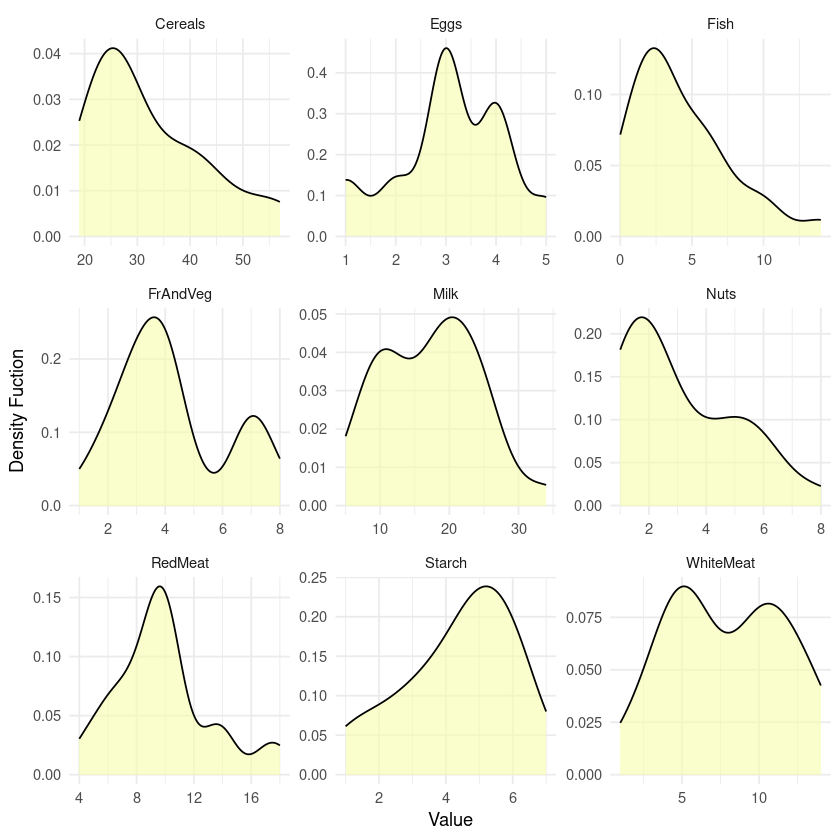

In [6]:
density_data <- d_protein %>% #select(Country,RedMeat,WhiteMeat,Eggs,Milk) %>% 
    pivot_longer(cols=-Country,names_to='type')
ggplot(density_data, aes(x=value)) + 
    geom_density(fill='#F6FEAA',alpha=0.6) + 
    facet_wrap(~type,scales='free') +
    labs(x='Value',y='Density Fuction') +
    theme_minimal() +
    theme(panel.grid.minor.y=element_blank())

### Choose a set of variables

In this example, we are likely to use all of the variables available in the data set. That is because we don't have a ton of options and due to the fact that the problem is quite simple. In other more complex situations we might choose to leave out certain variables or we might combine them in novel ways. For example, in this situation, we could narrow down our set of variables by combining the two meat categories by taking the row-wise maximum between RedMeat and WhiteMeat.

### Choose a transformation method (none being a viable option)

There quite a few ways to transform data. There are a few ways transform data that include collapsing rows via some kind of aggregation, collapsing columns (as discussed earlier), or to modifying the variables in some way. One very common modification when working with questionnaire data is to take what is called a Top 2 Box score. If you're dealing with some sort of agreement scale with 7 levels, a Top 2 Box score would assign the value 1 to scores 6 and 7 and 0 to all the lower scores. This is very helpful when evalutaing a solution but can also be used as an input into the clustering algorithm.

#### Consider units and scaling

Another very common data tranformation is to scale each variable by its mean and standard deviation. The documentation for this dataset doesn’t mention what the units of measurement are, though we can assume all the columns are measured in the same units. However, if we couldn't make that assumption, scaling would be come very important. This is important: units (or more precisely, disparity in units) affect what clusterings an algorithm will discover. If you measure vital statistics of your subjects as age in years, height in feet, and weight in pounds, you will very likely get different clusters if you measure age in years, height in meters, and weight in kilograms.

This is especially true if you want to cluster something like annual spend and customer age together. One will be measured in dollars (possibly tens of thousands of dollars) and the other will max out around 95 or so. The scales are terribly different and the variability will be quite different as well.

One way to try to make the clustering more coordinate-free is to transform all the columns to have a mean value of 0 and a standard deviation of 1. This makes the standard deviation the unit of measurement in each coordinate. Assuming that your training data has a distribution that accurately represents the population at large, then a standard deviation represents approximately the same degree of difference in every coordinate. You can scale the data in R using the function scale().

We're not using Country in the clustering (because it is not numeric). The following code will standardize all of the numeric variables.

In [7]:
var_list <- c("RedMeat", "WhiteMeat", "Eggs", "Milk", "Fish", "Cereals", "Starch", "Nuts", "FrAndVeg") 

m_protein <- as.data.frame(scale(d_protein[, var_list])) # filters to only the attributes we need and scales them
names(m_protein) <- paste0('st_',var_list)

all_protein <- cbind(d_protein,m_protein)

After standardization, we can look at the numerical summary of two variables to see if it worked. Note that the mean and standard deviation are now 0 and 1 respectively. This is the case for all of the variables in the data set.

In [8]:
summarize(all_protein,`Mean Red Meat`=round(mean(RedMeat),3),`StDev Red Meat`=sd(RedMeat)
          ,`Standardized Mean Red Meat`=round(mean(st_RedMeat),3),`Standardized StDev Red Meat`=sd(st_RedMeat)) %>% t() %>%
  knitr::kable()



|                            |        |
|:---------------------------|-------:|
|Mean Red Meat               | 9.80000|
|StDev Red Meat              | 3.40343|
|Standardized Mean Red Meat  | 0.00000|
|Standardized StDev Red Meat | 1.00000|

### Run several cluster algorithms

In this case, we will run what's called a K-means algorithm. This algorithm uses a mathematical definition of distance to cluster rows of data around a set of points. The user can specify which points to use as the basis for the distance calculation or the algorithm can choose them at random. This is the most commonly used cluster algorithm in my experience. Running a k-means cluster solution is quite easy as you can see below.

In [9]:
set.seed(42)
cluster_model <- kmeans(m_protein, centers=5)

### Evaluate solutions

The cluster algorithm will output some diagnostics (as seen below).

In [10]:
cluster_model


K-means clustering with 5 clusters of sizes 2, 11, 4, 2, 6

Cluster means:
   st_RedMeat st_WhiteMeat     st_Eggs    st_Milk     st_Fish st_Cereals
1 -0.96961017   -1.1815761 -0.96856767 -1.4483663  1.79232611 -0.3923599
2  0.77996190    0.3373154  0.66201763  0.8699420  0.31225559 -0.7804264
3 -0.82269954   -0.9142512 -1.41697862 -1.0961371 -1.01718829  1.7192995
4 -0.08814638   -1.0479136 -0.07174575 -0.1803413  0.06339417  0.6521168
5 -0.52887828    0.7342524  0.07772457 -0.3212330 -0.51291647  0.1979965
   st_Starch    st_Nuts st_FrAndVeg
1  0.9907602  1.1985682  1.72336879
2  0.2767978 -0.6249484 -0.38930094
3 -1.4257281  1.0747492 -0.62667956
4 -1.4257281  1.4462063  1.46225231
5  0.5880122 -0.4523522  0.06963106

Clustering vector:
 [1] 3 5 2 3 5 2 5 2 2 4 5 2 4 2 2 5 1 3 1 2 2 2 5 2 3

Within cluster sum of squares by cluster:
[1]  4.156111 41.389845  7.764725  2.784045 20.427644
 (between_SS / total_SS =  64.6 %)

Available components:

[1] "cluster"      "centers"      "totss

In my experience, the next step would be to look through the clusters to determine if the subjective meaning of the clusters is useful. To do this, we will look at the following table (the transpose of the cluster means seen above).

This table shows, for example, that cluster 1 is very high on Fish, Fruits and Vegetables, and Nuts. It is very low on Milk, Eggs and Red/White Meat. We might name this cluster "The Seaside Diet" based on this profile.

In [11]:
cluster_model$centers %>% t() %>% knitr::kable()




|             |          1|          2|          3|          4|          5|
|:------------|----------:|----------:|----------:|----------:|----------:|
|st_RedMeat   | -0.9696102|  0.7799619| -0.8226995| -0.0881464| -0.5288783|
|st_WhiteMeat | -1.1815761|  0.3373154| -0.9142512| -1.0479136|  0.7342524|
|st_Eggs      | -0.9685677|  0.6620176| -1.4169786| -0.0717458|  0.0777246|
|st_Milk      | -1.4483663|  0.8699420| -1.0961371| -0.1803413| -0.3212330|
|st_Fish      |  1.7923261|  0.3122556| -1.0171883|  0.0633942| -0.5129165|
|st_Cereals   | -0.3923599| -0.7804264|  1.7192995|  0.6521168|  0.1979965|
|st_Starch    |  0.9907602|  0.2767978| -1.4257281| -1.4257281|  0.5880122|
|st_Nuts      |  1.1985682| -0.6249484|  1.0747492|  1.4462063| -0.4523522|
|st_FrAndVeg  |  1.7233688| -0.3893009| -0.6266796|  1.4622523|  0.0696311|

#### Solution evaluation -- visuals

It is a common approach to plot the first two principal components of the clustered data. This is done using a method called Principal Component Analysis or PCA. The code below takes the final cluster solution, creates principal components from the inputs and plots the principal components where the points are colored based on the cluster assignment.

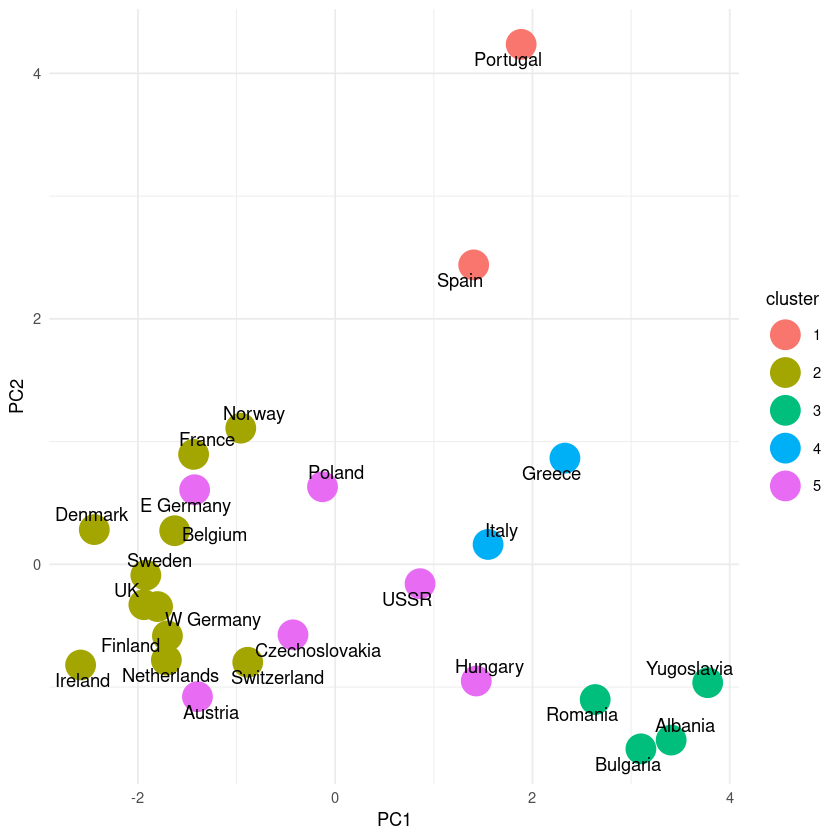

In [12]:
principal_components <- prcomp(m_protein)
number_components <- 2
projection <- predict(principal_components, newdata=m_protein)[,1:number_components]

projection_with_labels <- cbind(as.data.frame(projection),
                          cluster=as.factor(cluster_model$cluster),
                          country=d_protein$Country)

ggplot(projection_with_labels, aes(x=PC1, y=PC2)) +
  geom_point(aes(color=cluster), size=8) +
  geom_text_repel(aes(label = country)) +
  theme_minimal()

#### Number of clusters

Another question often asked regarding cluster solutions is how many clusters there should be. While there are various numeric measures to determine the number of clusters, the question is one often regarding how useful the solutions are to the business. Remember there's a lot of art going on here as we decide how to transform variables, which variables to use, and how we name the clusters (thereby presenting them to others).

The Datacamp chapter [https://app.datacamp.com/learn/assignments] explains how to determine the ideal number of clusters for your dataset that explains the most variance (minimizing within sum of squares).

# To-do

Log in to Datalab and click on SUBMIT-LAB5B*** file in the workspace for this course. You will then make a copy of that file and edit it for your homework assignment. The environment is already setup to complete the exercises.